## Laufzeiten der Sortieralgorithmen

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import random
import time 

#### Sortieralgorithmen mit quadratischer Laufzeit

In [3]:
def selection_sort(a):
    for i in range(len(a)-1):
        best = i
        best_val = a[i]
        for j in range(i+1,len(a)):
            if a[j] < best_val:
                best = j
                best_val = a[j]
        a[best],a[i] = a[i],a[best]

In [4]:
def bubble_sort(a):
    getauscht = True
    while getauscht:
        getauscht = False
        for i in range(len(a)-1):
            if a[i] > a[i+1]:
                a[i],a[i+1]=a[i+1],a[i]
                getauscht = True

In [5]:
def insertion_sort(a):
    for i in range(1,len(a)):
        x = a[i]
        j = i
        while j > 0 and a[j-1] > x:
            a[j] = a[j-1]
            j = j - 1
        a[j] = x
        

Verändere N und trage die entsprechenden Werte in die Listen anzahl und zeit ein.

In [33]:
N = 50          # Anzahl zu sortierender Elemente in Tausend
anzahl = 1    # Anzahl Versuche
summe = 0
for i in range(anzahl):
    a = [random.randint(-N*1000,N*1000) for _  in range(N*1000)] 
    start = time.perf_counter()
    bubble_sort(a)
    end = time.perf_counter()
    summe = summe + (end-start)

print(f'{summe/anzahl:.3f}')


217.677


In [25]:
anzahl = [1, 2, 4, 8, 16, 32]
selection = [0.016, 0.063, 0.254, 0.997, 4.103, 17.257]
bubble = [0.072, 0.303, 1.250, 5.131, 20.650, 87.676]
insertion=[0.024, 0.097, 0.397, 1.590, 6.470, 26.092 ]

In [26]:
parms1 = np.polyfit(anzahl, selection, 2)   # Parameter für die quadratische selections_sort Funktion
parms2 = np.polyfit(anzahl, bubble, 2)      # Parameter für die quadratische bubble_sort Funktion
parms3 = np.polyfit(anzahl, insertion, 2)   # Parameter für die quadratische insertion_sort Funktion


In [27]:
def f_sel(x):                               # die quadratische Funktion für Selection-sort
    return parms1[0]*x*x + parms1[1]*x + parms1[2]
def f_bub(x):
    return parms2[0]*x*x + parms2[1]*x + parms2[2]
def f_ins(x):
    return parms3[0]*x*x + parms3[1]*x + parms3[2]

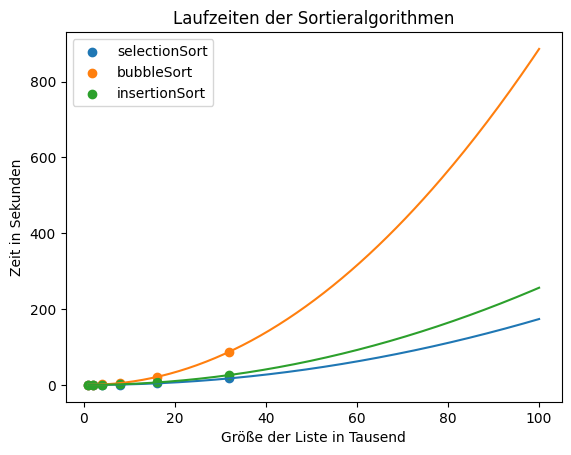

In [28]:
xmax = 100             # Bereich für die x-Achse
fig, ax = plt.subplots()
ax.scatter(anzahl,selection,label='selectionSort')
ax.scatter(anzahl,bubble,label='bubbleSort')
ax.scatter(anzahl,insertion,label='insertionSort')
ax.set_title('Laufzeiten der Sortieralgorithmen')
ax.set_xlabel('Größe der Liste in Tausend')
ax.set_ylabel('Zeit in Sekunden');
ax.legend();
xs = np.linspace(1,xmax,200)
ax.plot(xs,f_sel(xs),label='selectionSort');
ax.plot(xs,f_bub(xs),label='bubbleSort');
ax.plot(xs,f_ins(xs),label='insertionSort');


In [36]:
# predictions
f_bub(50)

np.float64(217.87362094975026)

In [53]:
zeit = 60*60   # zur Verfügung stehende Zeit in Sekunden
L = 50
R = 500
M = (L+R)/2

while abs(zeit-f_bub(M)) > 1:
    if f_bub(M) < zeit:
        L = M
    else:
        R = M
    M = (L+R)/2

# soviel Tausend können sortiert werden
print(M)   

200.732421875


In [51]:
f_bub(201)

np.float64(3610.4142523346877)